In [19]:
import os
import globals.path as pth
import nibabel as nb
import imaging_pipelines.model as md
import nitools as nt
import pandas as pd
import matplotlib.pyplot as plt
from util.util import get_trained_and_untrained
import PcmPy as pcm
import numpy as np

In [32]:
sn = 101
glm = 1
H = 'L'
roi = 'M1'
chord = 'trained'
corr = ['sess03', 'sess09']
cond_vec_mapping = {
            'sess03,0.0': 0,
            'sess03,1.0': 1,
            'sess03,2.0': 2,
            'sess03,3.0': 3,
            'sess09,0.0': 4,
            'sess09,1.0': 5,
            'sess09,2.0': 6,
            'sess09,3.0': 7,
            'sess23,0.0': 8,
            'sess23,1.0': 9,
            'sess23,2.0': 10,
            'sess23,3.0': 11,
        }

glm_path = os.path.join(pth.baseDir, f'glm{glm}')
roi_path = os.path.join(pth.baseDir, pth.roiDir)
betas = nb.load(os.path.join(glm_path, f'subj{sn}', 'beta.dscalar.nii'))
residuals = nb.load(os.path.join(glm_path, f'subj{sn}', 'ResMS.nii'))
mask = nb.load(os.path.join(roi_path, f'subj{sn}', f'ROI.{H}.{roi}.nii'))

# covert cifti betas to volums
betas = nt.volume_from_cifti(betas, struct_names=['CortexLeft', 'CortexRight'])

# do prewhitening
betas_prewhitened = md.calc_prewhitened_betas(betas, residuals, mask)

# get trained and untrained chords
trained_and_untrained = get_trained_and_untrained(sn)
trained, untrained = trained_and_untrained[:4], trained_and_untrained[4:]

# get regressor and partition info
reginfo = pd.read_csv(os.path.join(glm_path, f'subj{sn}', 'reginfo.tsv'), sep='\t')
sess = reginfo.name.str.split(',', n=1, expand=True).loc[:, 1]
chordID = reginfo.name.str.split(',', n=1, expand=True).loc[:, 0]
part_vec = (reginfo.run % 10).to_numpy()

# make booleans for chordID and session
chord_bool = chordID.isin(trained if chord=='trained' else untrained).to_numpy()
sess_bool = sess.isin(corr).to_numpy()

# map chordID to number for better control
chord_mapping = {val: i for i, val in enumerate(trained if chord=='trained' else untrained)}
chordID = chordID.map(chord_mapping) #.astype(int)

# apply bool to chordID, part_vec and betas
betas_prewhitened = betas_prewhitened[chord_bool & sess_bool]
chordID = chordID[chord_bool & sess_bool]
sess = sess[chord_bool & sess_bool]
part_vec = part_vec[chord_bool & sess_bool]

# make obs_vec
cond_vec = sess + ',' + chordID.astype(str)
cond_vec = cond_vec.map(cond_vec_mapping).to_numpy()
obs_des = {'cond_vec': cond_vec, 'part_vec': part_vec}

# remove mean
betas_prewhitened = betas_prewhitened - betas_prewhitened.mean(axis=1, keepdims=True)

# make Y and est G
Y = pcm.dataset.Dataset(betas_prewhitened, obs_descriptors=obs_des)
cov, _ = pcm.est_G(Y.measurements, Y.obs_descriptors['cond_vec'], Y.obs_descriptors['part_vec'])

Doing univariate prewhitening...


0.6434103131400795


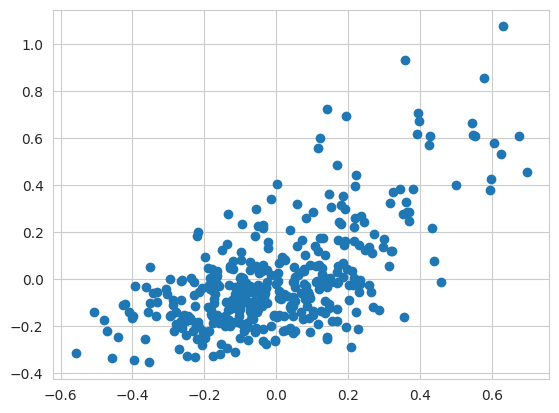

In [33]:
from scipy.stats import pearsonr
chord_n = 5
x1 = betas_prewhitened[0 + chord_n]
x2 = betas_prewhitened[40 + chord_n]
r, _ = pearsonr(x1, x2)
print(r)
plt.scatter(x1, x2)

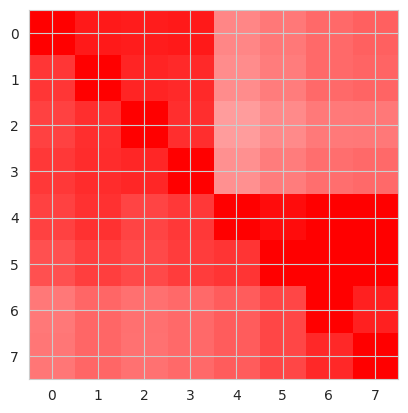

In [34]:
std = np.sqrt(np.diag(cov))  # shape: (N, k)
r = cov / (std * std)
plt.imshow(r, cmap='bwr', vmin=-1, vmax=1)